In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split

In [5]:
fake = pd.read_csv("archive/Fake.csv")
true = pd.read_csv("archive/True.csv")

In [6]:
fake["label"] = 1   # fake news
true["label"] = 0   # real news

In [7]:
fake = fake[["text","label"]]
true = true[["text","label"]]

In [8]:
df = pd.concat([fake,true])

df = df.sample(frac=1)   # shuffle dataset

df.reset_index(drop=True, inplace=True)

print(df.head())

                                                text  label
0  The mosque in Finsbury Park, London where this...      1
1  It s like a day doesn t go by without some bac...      1
2  If you haven t watched the commentary in Intel...      1
3  ROME (Reuters) - Italy s Senate passed into la...      0
4  WASHINGTON (Reuters) - U.S. President Donald T...      0


In [9]:
texts = df["text"]
labels = df["label"]

In [10]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

In [11]:
x = pad_sequences(sequences, maxlen=200)

y = np.array(labels)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
model = Sequential()

model.add(Embedding(5000,64,input_length=200))
model.add(LSTM(64))
model.add(Dense(1,activation="sigmoid"))

C:\Users\sindh\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 117s 101ms/step - accuracy: 0.9624 - loss: 0.1024 - val_accuracy: 0.9851 - val_loss: 0.0500
Epoch 2/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 178s 159ms/step - accuracy: 0.9871 - loss: 0.0399 - val_accuracy: 0.9856 - val_loss: 0.0503
Epoch 3/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 206s 183ms/step - accuracy: 0.9907 - loss: 0.0291 - val_accuracy: 0.9885 - val_loss: 0.0448
Epoch 4/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 87s 77ms/step - accuracy: 0.9950 - loss: 0.0163 - val_accuracy: 0.9902 - val_loss: 0.0395
Epoch 5/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 174s 106ms/step - accuracy: 0.9951 - loss: 0.0171 - val_accuracy: 0.9924 - val_loss: 0.0318


In [16]:
loss, accuracy = model.evaluate(x_test,y_test)

print("Test Accuracy:", accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9924 - loss: 0.0318
Test Accuracy: 0.9924275875091553


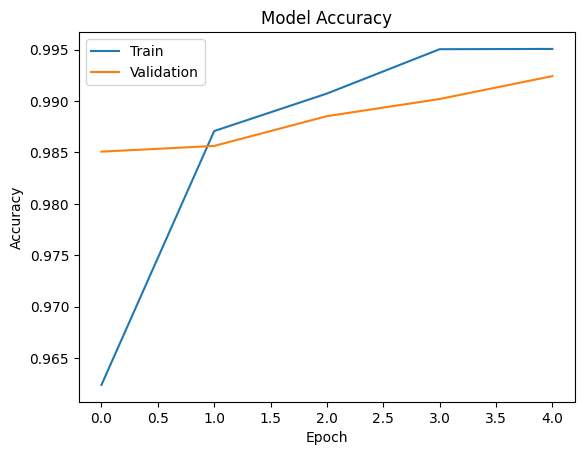

In [17]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [18]:
news = ["Aliens landed in New York City yesterday"]

seq = tokenizer.texts_to_sequences(news)
pad = pad_sequences(seq,maxlen=200)

prediction = model.predict(pad)

if prediction > 0.5:
    print("Fake News")
else:
    print("Real News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Fake News
